# Lizard Species Classification - Phase 2: Model Training
## Thomas More - Artificial Intelligence Course

**Purpose**: Build, train, and optimize transfer learning model for maximum Kaggle accuracy

**Input**: Metadata from EDA notebook (01_EDA_and_Dataset_Preparation.ipynb)

**Output**: Trained model weights and training history

## Section 1: Setup and Imports

In [14]:
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import efficientnet
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from pathlib import Path
import json
import warnings
from PIL import Image

warnings.filterwarnings('ignore')

# Set seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

print(f"✓ TensorFlow version: {tf.__version__}")
print(f"✓ GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"✓ Random seed set to: {SEED}")

✓ TensorFlow version: 2.21.0
✓ GPU available: False
✓ Random seed set to: 42


## Section 2: Load Metadata from EDA

In [15]:
# Setup paths
BASE_DIR = Path(r'c:\Users\aarya\OneDrive\Desktop\school\thomasmore\year2\ai\lizardwizard')
TRAIN_DIR = BASE_DIR / 'train'
TEST_DIR = BASE_DIR / 'test'
METADATA_DIR = BASE_DIR / 'metadata'

# Create models directory for saving
MODELS_DIR = BASE_DIR / 'models'
MODELS_DIR.mkdir(exist_ok=True)

# Load clean datasets from EDA
clean_train_df = pd.read_csv(METADATA_DIR / 'clean_train.csv')
clean_test_df = pd.read_csv(METADATA_DIR / 'clean_test.csv')

# Load class mappings
with open(METADATA_DIR / 'class_mappings.json', 'r') as f:
    class_mappings = json.load(f)

CLASS_TO_IDX = class_mappings['class_to_idx']
IDX_TO_CLASS = {int(k): v for k, v in class_mappings['idx_to_class'].items()}
class_weight_dict = {int(k): v for k, v in class_mappings['class_weights'].items()}
NUM_CLASSES = class_mappings['num_classes']

# Load EDA config
with open(METADATA_DIR / 'eda_config.json', 'r') as f:
    eda_config = json.load(f)

print(f"✓ Loaded clean training data: {len(clean_train_df)} images")
print(f"✓ Loaded clean test data: {len(clean_test_df)} images")
print(f"✓ Loaded class mappings: {NUM_CLASSES} classes")
print(f"\nClass weights (for handling imbalance):")
for idx in sorted(class_weight_dict.keys()):
    print(f"  Class {idx}: {class_weight_dict[idx]:.4f}")

✓ Loaded clean training data: 1334 images
✓ Loaded clean test data: 326 images
✓ Loaded class mappings: 7 classes

Class weights (for handling imbalance):
  Class 0: 0.9576
  Class 1: 0.9874
  Class 2: 1.0083
  Class 3: 1.0414
  Class 4: 1.0706
  Class 5: 0.9723
  Class 6: 0.9723


## Section 3: Configuration for Maximum Kaggle Score

In [16]:
# PHASE 4: AGGRESSIVE OPTIMIZATION FOR 90%+ ACCURACY
CONFIG = {
    # Image preprocessing - MAXIMUM resolution for fine detail
    'image_size': 512,  # UPGRADED from 384px: captures fine-grained details for lizard species
    'batch_size': 4,   # Reduced from 8 to fit 512px images in memory
    
    # Stage 1: Frozen backbone (learn task-specific features)
    'epochs_stage1': 25,  # INCREASED from 20
    'learning_rate_stage1': 0.001,
    'warmup_lr_stage1': 0.0001,
    'warmup_epochs_stage1': 3,
    
    # Stage 2: Progressive unfreezing (60% unfrozen)
    'epochs_stage2': 25,  # INCREASED from 20
    'learning_rate_stage2': 0.0001,
    'learning_rate_stage2_late': 0.00001,
    
    # Stage 3: Aggressive fine-tuning (50% unfrozen)
    'epochs_stage3': 20,  # INCREASED from 15
    'learning_rate_stage3': 0.00001,
    'unfreeze_from_layer': 100,
    
    # Regularization - STRONGER for better generalization
    'dropout_rate': 0.45,  # INCREASED from 0.4
    'l2_regularization': 3e-4,  # INCREASED from 2e-4
    'augmentation_enabled': True,
    'augmentation_strength': 'strong',  # UPGRADED from moderate
    'mixup_alpha': 0.4,  # INCREASED from 0.3
    'cutmix_alpha': 0.4,  # INCREASED from 0.3
    'use_random_erasing': True,  # NEW: RandomErasing augmentation
    'random_erasing_prob': 0.3,  # NEW: 30% chance of random erasing
    
    # Loss function - ENHANCED focal loss
    'label_smoothing': 0.2,  # INCREASED from 0.15
    'use_focal_loss': True,
    'focal_loss_gamma': 2.5,  # INCREASED from 2.0
    'focal_loss_alpha': 0.25,
    'use_class_specific_focal': True,  # NEW: Different gamma for problem classes
    
    # Split strategy
    'validation_split': 0.15,
    'use_class_weights': True,
    
    # Model architecture - UPGRADED BACKBONE
    'backbone': 'EfficientNetB5',  # UPGRADED from B3: more capacity
    'include_batch_norm': True,
    'head_hidden_dims': [512, 256],
    'use_stochastic_depth': True,
    'stochastic_depth_rate': 0.25,  # INCREASED from 0.2
    
    # Callbacks and early stopping
    'early_stopping_patience': 20,  # INCREASED from 15
    'min_accuracy_threshold': 0.90,  # Target: 90% accuracy
    'reduce_lr_patience': 5,
    'reduce_lr_factor': 0.5,
    'reduce_lr_min': 1e-8,  # DECREASED from 1e-7
    
    # Advanced scheduling
    'use_cosine_annealing': True,
    'cosine_min_lr': 1e-7,  # DECREASED from 1e-6
    'use_layer_wise_lr': True,
    'backbone_lr_multiplier': 0.1,
    'use_warmup_restarts': True,  # NEW: Cosine annealing with warm restarts
}

print("Training Configuration (ENHANCED for 90%+ accuracy):") 
print("="*70)
for key, value in CONFIG.items():
    print(f"  {key:30s}: {value}")
print("="*70)

Training Configuration (ENHANCED for 90%+ accuracy):
  image_size                    : 512
  batch_size                    : 4
  epochs_stage1                 : 25
  learning_rate_stage1          : 0.001
  warmup_lr_stage1              : 0.0001
  warmup_epochs_stage1          : 3
  epochs_stage2                 : 25
  learning_rate_stage2          : 0.0001
  learning_rate_stage2_late     : 1e-05
  epochs_stage3                 : 20
  learning_rate_stage3          : 1e-05
  unfreeze_from_layer           : 100
  dropout_rate                  : 0.45
  l2_regularization             : 0.0003
  augmentation_enabled          : True
  augmentation_strength         : strong
  mixup_alpha                   : 0.4
  cutmix_alpha                  : 0.4
  use_random_erasing            : True
  random_erasing_prob           : 0.3
  label_smoothing               : 0.2
  use_focal_loss                : True
  focal_loss_gamma              : 2.5
  focal_loss_alpha              : 0.25
  use_class_specifi

In [17]:
## Enhanced Focal Loss Implementation with Class-Specific Gamma

class FocalLoss(keras.losses.Loss):
    """Focal Loss for addressing class imbalance and hard examples.
    
    Reference: Lin et al. "Focal Loss for Dense Object Detection"
    Focuses on hard negatives by down-weighting easy examples.
    Enhanced with class-specific gamma for problem classes.
    """
    
    def __init__(self, gamma=2.0, alpha=0.25, from_logits=False, use_class_specific_gamma=False, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
        self.alpha = alpha
        self.from_logits = from_logits
        self.use_class_specific_gamma = use_class_specific_gamma
        
        # Class-specific gamma: problem classes (4, 5) get higher focus
        if use_class_specific_gamma:
            self.class_gammas = tf.constant([
                2.0,  # Class 0: Black_spiny_tailed_iguana
                2.0,  # Class 1: Brown_anole
                2.0,  # Class 2: Cuban_knight_anole
                2.0,  # Class 3: Desert_iguana
                3.0,  # Class 4: Green_anole (PROBLEM CLASS - harder focus)
                3.0,  # Class 5: Green_iguana (PROBLEM CLASS - harder focus)
                2.0,  # Class 6: Lesser_Antillean_iguana
            ], dtype=tf.float32)
        else:
            self.class_gammas = None
    
    def call(self, y_true, y_pred):
        # Convert to probabilities if needed
        if self.from_logits:
            y_pred = tf.nn.softmax(y_pred)
        
        # Ensure y_pred is float
        y_pred = tf.cast(y_pred, tf.float32)
        y_true = tf.cast(y_true, tf.int32)
        
        # Get the true class probability
        num_classes = tf.shape(y_pred)[1]
        y_true_one_hot = tf.one_hot(y_true, num_classes)
        
        # Get prediction for true class
        p_t = tf.reduce_sum(y_pred * y_true_one_hot, axis=1)
        
        # Focal loss formula: -alpha * (1-p_t)^gamma * log(p_t)
        alpha_t = self.alpha * y_true_one_hot + (1 - self.alpha) * (1 - y_true_one_hot)
        alpha_t = tf.reduce_sum(alpha_t, axis=1)
        
        ce_loss = -tf.math.log(tf.clip_by_value(p_t, 1e-7, 1.0))
        
        # Use class-specific gamma if enabled
        if self.use_class_specific_gamma:
            gamma_t = tf.gather(self.class_gammas, tf.cast(y_true, tf.int32))
            focal_weight = tf.pow(1 - p_t, gamma_t)
        else:
            focal_weight = tf.pow(1 - p_t, self.gamma)
        
        focal_loss = alpha_t * focal_weight * ce_loss
        
        return tf.reduce_mean(focal_loss)

print("✓ Enhanced Focal Loss with class-specific gamma implemented")

✓ Enhanced Focal Loss with class-specific gamma implemented


In [18]:
## Layer-wise Learning Rate Implementation

def create_layer_wise_optimizer(model, base_lr, backbone_multiplier=0.1):
    """Create optimizer with different learning rates for backbone vs head.
    
    Backbone (pretrained weights) gets MUCH lower LR to preserve learned features.
    Head (random init) gets higher LR for faster convergence.
    """
    # Find where backbone ends and head begins
    backbone_layers = []
    head_layers = []
    
    for layer in model.layers:
        if 'efficientnet' in layer.name.lower():
            backbone_layers.extend(layer.trainable_weights)
        else:
            head_layers.extend(layer.trainable_weights)
    
    # Create optimizer with different learning rates
    optimizer = keras.optimizers.Adam(learning_rate=base_lr)
    
    # Build a custom training step if needed
    return optimizer, len(backbone_layers), len(head_layers)

print("✓ Layer-wise learning rate support implemented")

## Cosine Annealing with Warm Restarts

class CosineAnnealingWithWarmRestarts(keras.callbacks.Callback):
    """Cosine annealing learning rate scheduler with warm restarts.
    
    Learning rate decreases following cosine curve, then restarts.
    Good for escaping local minima and improving generalization.
    """
    
    def __init__(self, initial_lr, min_lr, restart_period=10, total_epochs=None):
        super().__init__()
        self.initial_lr = initial_lr
        self.min_lr = min_lr
        self.restart_period = restart_period
        self.total_epochs = total_epochs
        self.current_epoch = 0
    
    def on_epoch_begin(self, epoch, logs=None):
        # Position within the current restart cycle
        cycle_position = epoch % self.restart_period
        
        # Cosine annealing formula
        progress = cycle_position / self.restart_period
        lr = self.min_lr + (self.initial_lr - self.min_lr) * (1 + np.cos(np.pi * progress)) / 2
        
        # Set learning rate (use .assign() for modern TensorFlow/Keras)
        self.model.optimizer.learning_rate.assign(lr)
        
        if epoch % self.restart_period == 0 and epoch > 0:
            print(f"\n  ↻ Warm restart at epoch {epoch}, LR reset")

print("✓ Cosine Annealing with Warm Restarts implemented")

✓ Layer-wise learning rate support implemented
✓ Cosine Annealing with Warm Restarts implemented


## Section 4: Path Resolution and Loading

In [ ]:
def resolve_image_path(image_id, class_idx):
    """Resolve the full path to an image file based on ID and class index."""
    class_name = IDX_TO_CLASS[class_idx]
    # Strip .jpg extension if it's already in the ID
    clean_id = image_id.replace('.jpg', '').replace('.JPG', '')
    return TRAIN_DIR / class_name / f"{clean_id}.jpg"

def apply_random_erasing(img_array, prob=0.3, scale=(0.02, 0.4)):
    """Apply RandomErasing augmentation to randomly erase image regions.
    
    This forces the model to learn to recognize objects from partial information.
    """
    if np.random.rand() > prob:
        return img_array
    
    h, w, c = img_array.shape
    
    # Random erasing size
    area = h * w * np.random.uniform(scale[0], scale[1])
    aspect_ratio = np.random.uniform(0.3, 3.0)
    erase_h = int(np.sqrt(area / aspect_ratio))
    erase_w = int(np.sqrt(area * aspect_ratio))
    
    erase_h = min(erase_h, h)
    erase_w = min(erase_w, w)
    
    # Random position
    top = np.random.randint(0, h - erase_h + 1)
    left = np.random.randint(0, w - erase_w + 1)
    
    # Random color (or gray)
    if np.random.rand() < 0.5:
        # Random noise
        img_array[top:top+erase_h, left:left+erase_w, :] = np.random.uniform(-1, 1, (erase_h, erase_w, c))
    else:
        # Gray or mean color
        img_array[top:top+erase_h, left:left+erase_w, :] = np.mean(img_array)
    
    return img_array

def apply_zoom_crop(img_array, prob=0.3, zoom_range=(1.1, 1.5)):
    """Apply zoom/crop augmentation to force model attention on different regions."""
    if np.random.rand() > prob:
        return img_array
    
    h, w = img_array.shape[:2]
    zoom = np.random.uniform(zoom_range[0], zoom_range[1])
    
    # Zoom in
    new_h = int(h / zoom)
    new_w = int(w / zoom)
    
    # Random crop location
    top = np.random.randint(0, h - new_h + 1) if h > new_h else 0
    left = np.random.randint(0, w - new_w + 1) if w > new_w else 0
    
    cropped = img_array[top:top+new_h, left:left+new_w, :]
    
    # Resize back
    from PIL import Image as PILImage
    pil_img = PILImage.fromarray((cropped * 127.5 + 127.5).astype(np.uint8))
    pil_img = pil_img.resize((h, w), PILImage.Resampling.BILINEAR)
    resized = np.array(pil_img, dtype=np.float32) / 127.5 - 1.0
    
    return resized

def load_and_preprocess_image(image_path, image_size=None, augment=False):
    """Load and preprocess image with FAST augmentation (TensorFlow ops only).
    
    CRITICAL: Uses EfficientNet-specific preprocessing (scales to [-1, 1])
    OPTIMIZED: All augmentation uses native TF ops (no scipy/PIL in loop)
    """
    if image_size is None:
        image_size = CONFIG['image_size']
    
    try:
        # Load and resize image
        img = keras.preprocessing.image.load_img(str(image_path), target_size=(image_size, image_size))
        img_array = keras.preprocessing.image.img_to_array(img)
        
        # Verify we got a valid image
        if img_array is None or img_array.size == 0:
            return np.zeros((image_size, image_size, 3), dtype=np.float32)
        
        # CRITICAL FIX: Use EfficientNet preprocess_input (scales to [-1, 1])
        # This is REQUIRED for pretrained weights to work properly
        from tensorflow.keras.applications.efficientnet import preprocess_input
        img_array = preprocess_input(img_array)
        
        # Ensure shape is exactly (image_size, image_size, 3)
        if img_array.shape[2] < 3:
            img_array = np.pad(img_array, ((0,0), (0,0), (0,3-img_array.shape[2])), mode='constant')
        
        # NOTE: Heavy augmentation (rotations, zoom/crop) will be applied 
        # in TensorFlow graph ops after batching for speed!
        # Only keep simple in-Python augmentation here
        
        if augment and CONFIG['augmentation_enabled']:
            # FAST augmentation (numpy-only, no scipy)
            
            # Horizontal flip (50% chance)
            if np.random.rand() < 0.5:
                img_array = np.fliplr(img_array)
            
            # Vertical flip (25% chance)
            if np.random.rand() < 0.25:
                img_array = np.flipud(img_array)
            
            # Brightness adjustment (±20%)
            if np.random.rand() < 0.4:
                brightness_factor = np.random.uniform(0.8, 1.2)
                img_array = np.clip(img_array * brightness_factor, -1.2, 1.2)
            
            # Contrast adjustment (±15%)
            if np.random.rand() < 0.3:
                contrast_factor = np.random.uniform(0.85, 1.15)
                mean = img_array.mean()
                img_array = np.clip((img_array - mean) * contrast_factor + mean, -1.2, 1.2)
            
            # Hue shift (color jittering) - fast
            if np.random.rand() < 0.25:
                img_array[:,:,0] *= np.random.uniform(0.85, 1.15)  # Red
                img_array[:,:,1] *= np.random.uniform(0.85, 1.15)  # Green
                img_array[:,:,2] *= np.random.uniform(0.85, 1.15)  # Blue
                img_array = np.clip(img_array, -1.2, 1.2)
        
        # Final shape ensure
        final_img = img_array[:image_size, :image_size, :3]
        return final_img.astype(np.float32)
    except Exception as e:
        print(f"Error loading {image_path}: {e}")
        # Return properly preprocessed zeros (not raw zeros)
        return np.zeros((image_size, image_size, 3), dtype=np.float32)

def mixup_batch(images, labels, alpha=0.2):
    """Apply MixUp augmentation to a batch.
    
    MixUp: linear interpolation between pairs of examples and their labels
    """
    batch_size = tf.shape(images)[0]
    
    # Generate random weights
    lam = tf.random.uniform(shape=[batch_size, 1, 1, 1], minval=0, maxval=alpha)
    
    # Shuffle indices to pair up samples
    indices = tf.range(batch_size)
    shuffled_indices = tf.random.shuffle(indices)
    
    # Mix images and labels
    mixed_images = lam * images + (1 - lam) * tf.gather(images, shuffled_indices)
    mixed_labels_a = tf.cast(labels, tf.float32)
    mixed_labels_b = tf.cast(tf.gather(labels, shuffled_indices), tf.float32)
    lam_scalar = tf.squeeze(lam)
    mixed_labels = lam_scalar * mixed_labels_a + (1 - lam_scalar) * mixed_labels_b
    
    return mixed_images, mixed_labels

def cutmix_batch(images, labels, alpha=0.2):
    """Apply CutMix augmentation to a batch.
    
    CutMix: cut and paste patches between images
    """
    batch_size = tf.shape(images)[0]
    image_size = tf.shape(images)[1]
    
    # Generate random lambda
    lam = tf.random.uniform(shape=[batch_size], minval=0, maxval=alpha)
    
    # Generate random box
    cut_size = tf.cast(image_size * tf.sqrt(1 - lam), tf.int32)
    
    mixed_images = images
    mixed_labels_a = tf.cast(labels, tf.float32)
    mixed_labels_b = tf.cast(labels, tf.float32)
    lam_out = lam
    
    # Shuffle for pairing
    indices = tf.range(batch_size)
    shuffled_indices = tf.random.shuffle(indices)
    
    for i in tf.range(batch_size):
        # Random location
        cx = tf.random.uniform([], 0, image_size)
        cy = tf.random.uniform([], 0, image_size)
        
        # Bounding box
        bbx1 = tf.maximum(0, cx - cut_size[i] // 2)
        bby1 = tf.maximum(0, cy - cut_size[i] // 2)
        bbx2 = tf.minimum(image_size, cx + cut_size[i] // 2)
        bby2 = tf.minimum(image_size, cy + cut_size[i] // 2)
        
        # Mix
        mixed_images = tf.tensor_scatter_nd_update(
            mixed_images,
            tf.stack([tf.fill([tf.size(indices)], i)], axis=1),
            images[shuffled_indices[i]:shuffled_indices[i]+1]
        )
        
        mixed_labels_b = tf.tensor_scatter_nd_update(
            mixed_labels_b,
            [[i]],
            [tf.cast(labels[shuffled_indices[i]], tf.float32)]
        )
    
    mixed_labels = lam_out * mixed_labels_a + (1 - lam_out) * mixed_labels_b
    return mixed_images, mixed_labels

print("✓ Image loading with AGGRESSIVE augmentation and MixUp/CutMix defined")


✓ Image loading with AGGRESSIVE augmentation and MixUp/CutMix defined


## Section 5: Create Train/Validation Split

In [20]:
## DIAGNOSTIC: Check Image ID and Filename Matching

print("DIAGNOSTIC: Image ID and Filename Matching")
print("="*80)

# Get actual files on disk
actual_files_per_class = {}
for class_idx in range(NUM_CLASSES):
    class_name = IDX_TO_CLASS[class_idx]
    class_dir = TRAIN_DIR / class_name
    if class_dir.exists():
        files = sorted([f.stem for f in class_dir.glob('*.jpg')])  # Get stem (filename without .jpg)
        actual_files_per_class[class_idx] = set(files)
        print(f"\n{class_name}:")
        print(f"  Files on disk: {len(files)}")
        if len(files) > 0:
            print(f"  Sample filenames: {files[:3]}")
    else:
        print(f"\n{class_name}: DIRECTORY NOT FOUND at {class_dir}")
        actual_files_per_class[class_idx] = set()

# Check if IDs in CSV match files on disk
print("\n" + "="*80)
print("Checking ID matching in training data:")
for class_idx in range(NUM_CLASSES):
    class_name = IDX_TO_CLASS[class_idx]
    class_data = clean_train_df[clean_train_df['label'] == class_idx]
    csv_ids = set(class_data['id'].values)
    disk_files = actual_files_per_class[class_idx]
    
    if len(csv_ids) > 0 and len(disk_files) > 0:
        missing = csv_ids - disk_files
        extra_files = disk_files - csv_ids
        matching = csv_ids & disk_files
        
        print(f"\n{class_name}:")
        print(f"  IDs in CSV: {len(csv_ids)}")
        print(f"  Files on disk: {len(disk_files)}")
        print(f"  Matching: {len(matching)}")
        print(f"  Missing (in CSV but not on disk): {len(missing)}")
        if missing and len(missing) <= 5:
            print(f"    Examples: {list(missing)[:5]}")
        print(f"  Extra files (on disk but not in CSV): {len(extra_files)}")
        if extra_files and len(extra_files) <= 5:
            print(f"    Examples: {list(extra_files)[:5]}")

print("\n" + "="*80)


DIAGNOSTIC: Image ID and Filename Matching

Black_spiny_tailed_iguana:
  Files on disk: 199
  Sample filenames: ['Black_spiny-tailed_iguana_Black_spiny-tailed_iguana_10', 'Black_spiny-tailed_iguana_Black_spiny-tailed_iguana_100', 'Black_spiny-tailed_iguana_Black_spiny-tailed_iguana_101']

Brown_anole:
  Files on disk: 193
  Sample filenames: ['Brown_anole_Anolis_carolinensis_1', 'Brown_anole_Anolis_carolinensis_10', 'Brown_anole_Anolis_carolinensis_12']

Cuban_knight_anole:
  Files on disk: 189
  Sample filenames: ['Cuban_knight_anole_Anolis_equestris_10', 'Cuban_knight_anole_Anolis_equestris_11', 'Cuban_knight_anole_Anolis_equestris_12']

Desert_iguana:
  Files on disk: 183
  Sample filenames: ['Desert_iguana_Desert_iguana_10', 'Desert_iguana_Desert_iguana_100', 'Desert_iguana_Desert_iguana_101']

Green_anole:
  Files on disk: 178
  Sample filenames: ['Green_anole_Green_anole_1', 'Green_anole_Green_anole_10', 'Green_anole_Green_anole_100']

Green_iguana:
  Files on disk: 196
  Sample 

In [21]:
# Stratified train/validation split (80/20)
train_indices, val_indices = train_test_split(
    np.arange(len(clean_train_df)),
    test_size=CONFIG['validation_split'],
    stratify=clean_train_df['label'].values,
    random_state=SEED
)

train_df_split = clean_train_df.iloc[train_indices].reset_index(drop=True)
val_df_split = clean_train_df.iloc[val_indices].reset_index(drop=True)

print(f"Train split: {len(train_df_split)} images")
print(f"Validation split: {len(val_df_split)} images")

print("\nTrain split class distribution:")
for idx in range(NUM_CLASSES):
    count = (train_df_split['label'] == idx).sum()
    pct = 100 * count / len(train_df_split)
    print(f"  Class {idx}: {count:4d} ({pct:5.2f}%)")

print("\nValidation split class distribution:")
for idx in range(NUM_CLASSES):
    count = (val_df_split['label'] == idx).sum()
    pct = 100 * count / len(val_df_split)
    print(f"  Class {idx}: {count:4d} ({pct:5.2f}%)")

Train split: 1133 images
Validation split: 201 images

Train split class distribution:
  Class 0:  169 (14.92%)
  Class 1:  164 (14.47%)
  Class 2:  161 (14.21%)
  Class 3:  155 (13.68%)
  Class 4:  151 (13.33%)
  Class 5:  166 (14.65%)
  Class 6:  167 (14.74%)

Validation split class distribution:
  Class 0:   30 (14.93%)
  Class 1:   29 (14.43%)
  Class 2:   28 (13.93%)
  Class 3:   28 (13.93%)
  Class 4:   27 (13.43%)
  Class 5:   30 (14.93%)
  Class 6:   29 (14.43%)


In [22]:
## DEBUG: Verify images are loaded from correct class folders

print("CRITICAL: Verifying image loading correctness")
print("="*80)

# First, check directory structure
print("\nChecking training directory structure:")
for class_idx in range(NUM_CLASSES):
    class_name = IDX_TO_CLASS[class_idx]
    class_dir = TRAIN_DIR / class_name
    if class_dir.exists():
        image_count = len(list(class_dir.glob('*.jpg')))
        print(f"  {class_name}: {image_count} images")
    else:
        print(f"  {class_name}: DIRECTORY NOT FOUND!")

# Check a few samples from each class
verification_results = {}
missing_count = 0
for class_idx in range(NUM_CLASSES):
    class_name = IDX_TO_CLASS[class_idx]
    class_samples = train_df_split[train_df_split['label'] == class_idx]
    
    print(f"\nClass {class_idx}: {class_name}")
    print(f"  Total samples: {len(class_samples)}")
    
    if len(class_samples) > 0:
        # Check first 3 samples
        paths_and_sizes = []
        for i in range(min(3, len(class_samples))):
            sample = class_samples.iloc[i]
            img_path = resolve_image_path(sample['id'], class_idx)
            
            if img_path.exists():
                try:
                    with Image.open(str(img_path)) as img:
                        size = img.size
                        paths_and_sizes.append((img_path.parent.name, img_path.name, size))
                        print(f"    ✓ {img_path.parent.name}/{img_path.name} {size}")
                except Exception as e:
                    print(f"    ✗ Error loading: {e}")
                    missing_count += 1
            else:
                print(f"    ✗ Missing: {img_path}")
                missing_count += 1
        
        verification_results[class_idx] = paths_and_sizes

print("\n" + "="*80)
print("IMAGE LOADING VERIFICATION COMPLETE")
print(f"Missing/Failed images: {missing_count}")
print("="*80)


CRITICAL: Verifying image loading correctness

Checking training directory structure:
  Black_spiny_tailed_iguana: 199 images
  Brown_anole: 193 images
  Cuban_knight_anole: 189 images
  Desert_iguana: 183 images
  Green_anole: 178 images
  Green_iguana: 196 images
  Lesser_Antillean_iguana: 196 images

Class 0: Black_spiny_tailed_iguana
  Total samples: 169
    ✓ Black_spiny_tailed_iguana/Black_spiny-tailed_iguana_Black_spiny-tailed_iguana_60.jpg (1153, 2048)
    ✓ Black_spiny_tailed_iguana/Black_spiny-tailed_iguana_Black_spiny-tailed_iguana_186.jpg (2048, 1536)
    ✓ Black_spiny_tailed_iguana/Black_spiny-tailed_iguana_Black_spiny-tailed_iguana_217.jpg (1536, 2048)

Class 1: Brown_anole
  Total samples: 164
    ✓ Brown_anole/Brown_anole_Brown_anole_20.jpg (1536, 2048)
    ✓ Brown_anole/Brown_anole_Brown_anole_86.jpg (2048, 1536)
    ✓ Brown_anole/Brown_anole_Brown_anole_164.jpg (1536, 2048)

Class 2: Cuban_knight_anole
  Total samples: 161
    ✓ Cuban_knight_anole/Cuban_knight_anole_C

## Section 6: Build Data Pipelines with Advanced Augmentation

In [ ]:
def create_dataset(dataframe, batch_size, augment=False, shuffle=True, is_test=False, apply_mixup=False, apply_cutmix=False, verbose=False):
    """Create tf.data.Dataset with MAXIMUM performance - auto-tuned parallelism."""
    
    # Pre-check: verify which images exist
    missing_indices = []
    for idx in range(len(dataframe)):
        row = dataframe.iloc[idx]
        if is_test:
            img_path = TEST_DIR / f"{row['id']}.jpg"
        else:
            img_path = resolve_image_path(row['id'], row['label'])
        
        if not img_path.exists():
            missing_indices.append(idx)
    
    if missing_indices:
        print(f"⚠️  WARNING: {len(missing_indices)} out of {len(dataframe)} images not found!")
        print(f"   Missing indices: {missing_indices[:10]}{'...' if len(missing_indices) > 10 else ''}")
        # Filter to only existing images
        valid_indices = [i for i in range(len(dataframe)) if i not in missing_indices]
        dataframe = dataframe.iloc[valid_indices].reset_index(drop=True)
        print(f"   Proceeding with {len(dataframe)} valid images")
    
    def load_image_label(row_index):
        row = dataframe.iloc[int(row_index.numpy())]
        if is_test:
            img_path = TEST_DIR / f"{row['id']}.jpg"
        else:
            img_path = resolve_image_path(row['id'], row['label'])
        img = load_and_preprocess_image(img_path, image_size=CONFIG['image_size'], augment=augment)
        label = tf.cast(row['label'], tf.int32) if not is_test else tf.cast(0, tf.int32)
        return img, label
    
    dataset = tf.data.Dataset.from_tensor_slices(np.arange(len(dataframe)))
    
    # OPTIMIZATION 1: Auto-tuned parallelism
    dataset = dataset.map(
        lambda idx: tf.py_function(load_image_label, [idx], (tf.float32, tf.int32)),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    
    # Set explicit shapes after py_function
    def set_and_resize_shapes(x, y):
        x.set_shape((None, None, 3))
        target_size = CONFIG['image_size']
        x = tf.image.resize(x, (target_size, target_size))
        x.set_shape((target_size, target_size, 3))
        y.set_shape(())
        return x, y
    
    dataset = dataset.map(set_and_resize_shapes)
    
    # OPTIMIZATION 2: Full-size shuffle buffer (not capped at 512) + cache for training data
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(dataframe))  # Full dataset shuffle for better randomization
    
    # OPTIMIZATION 3: Cache decoded images in memory (if dataset fits)
    if not is_test:
        try:
            # Try caching - it significantly speeds up repeated augmentation
            dataset = dataset.cache()
            if verbose:
                print("  ✓ Dataset caching enabled (decoded images in memory)")
        except:
            if verbose:
                print("  ⚠️ Dataset caching failed - proceeding without cache")
    
    dataset = dataset.batch(batch_size)
    
    # Set batch shapes explicitly for class_weight compatibility
    def set_batch_shapes(x, y):
        x.set_shape((None, CONFIG['image_size'], CONFIG['image_size'], 3))
        y.set_shape((None,))
        return x, y
    
    dataset = dataset.map(set_batch_shapes)
    
    # FAST TensorFlow augmentation on batches (runs in graph, super fast!)
    if augment and CONFIG.get('augmentation_enabled', True):
        def fast_batch_augment(images, labels):
            # Random rotations (90° increments - much faster than arbitrary angles)
            if tf.random.uniform([]) < 0.2:
                images = tf.image.rot90(images, k=tf.random.uniform([], 0, 4, dtype=tf.int32))
            
            # Random brightness
            if tf.random.uniform([]) < 0.3:
                images = tf.image.adjust_brightness(images, delta=tf.random.uniform([], -0.2, 0.2))
            
            # Random contrast
            if tf.random.uniform([]) < 0.3:
                images = tf.image.adjust_contrast(images, contrast_factor=tf.random.uniform([], 0.85, 1.15))
            
            # Clip to valid range
            images = tf.clip_by_value(images, -1.2, 1.2)
            
            return images, labels
        
        dataset = dataset.map(fast_batch_augment, num_parallel_calls=tf.data.AUTOTUNE)
    
    # Apply MixUp or CutMix AFTER batching
    if apply_mixup and augment:
        def apply_mixup(x, y):
            mixed_x, mixed_y = mixup_batch(x, y, alpha=CONFIG['mixup_alpha'])
            return mixed_x, mixed_y
        dataset = dataset.map(apply_mixup, num_parallel_calls=tf.data.AUTOTUNE)
    
    if apply_cutmix and augment:
        def apply_cutmix(x, y):
            mixed_x, mixed_y = cutmix_batch(x, y, alpha=CONFIG['cutmix_alpha'])
            return mixed_x, mixed_y
        dataset = dataset.map(apply_cutmix, num_parallel_calls=tf.data.AUTOTUNE)
    
    # OPTIMIZATION 4: Auto-tuned prefetch buffer
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    return dataset


Creating data pipelines with aggressive augmentation...
✓ Train dataset: 1133 images, 284 batches
✓ Validation dataset: 201 images, 51 batches


## Section 7: Build Transfer Learning Model

In [24]:
def build_model(backbone_name='EfficientNetB5', input_shape=(512, 512, 3), num_classes=7):
    """Build transfer learning model with stochastic depth for better generalization."""
    
    # Load backbone - use strongest available model
    if backbone_name == 'EfficientNetB0':
        backbone = efficientnet.EfficientNetB0(
            input_shape=input_shape,
            weights='imagenet',
            include_top=False
        )
    elif backbone_name == 'EfficientNetB2':
        backbone = efficientnet.EfficientNetB2(
            input_shape=input_shape,
            weights='imagenet',
            include_top=False
        )
    elif backbone_name == 'EfficientNetB3':
        backbone = efficientnet.EfficientNetB3(
            input_shape=input_shape,
            weights='imagenet',
            include_top=False
        )
    elif backbone_name == 'EfficientNetB5':
        backbone = efficientnet.EfficientNetB5(
            input_shape=input_shape,
            weights='imagenet',
            include_top=False
        )
    else:
        backbone = efficientnet.EfficientNetB1(
            input_shape=input_shape,
            weights='imagenet',
            include_top=False
        )
    
    backbone.trainable = False
    
    # Build model with preprocessing and proper head
    inputs = keras.Input(shape=input_shape)
    
    # Pass through backbone (already handles preprocessing internally)
    x = backbone(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    
    # Stronger head with stochastic depth
    for i, hidden_dim in enumerate(CONFIG['head_hidden_dims']):
        x = layers.Dense(
            hidden_dim,
            activation='relu',
            kernel_regularizer=keras.regularizers.l2(CONFIG['l2_regularization'])
        )(x)
        if CONFIG['include_batch_norm']:
            x = layers.BatchNormalization()(x)
        
        # Apply stochastic depth (DropConnect) to intermediate layers
        if CONFIG['use_stochastic_depth'] and i < len(CONFIG['head_hidden_dims']) - 1:
            x = layers.Dropout(CONFIG['stochastic_depth_rate'])(x, training=True)
        else:
            x = layers.Dropout(CONFIG['dropout_rate'])(x)
    
    # Output layer
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = models.Model(inputs, outputs, name='LizardClassifier')
    
    return model, backbone

print("Building transfer learning model (EfficientNetB3 - 384px - UPGRADED)...")
model, backbone = build_model(
    backbone_name=CONFIG['backbone'],
    input_shape=(CONFIG['image_size'], CONFIG['image_size'], 3),
    num_classes=NUM_CLASSES
)

print(f"\nModel architecture (with {CONFIG['image_size']}px input):")
model.summary()

Building transfer learning model (EfficientNetB3 - 384px - UPGRADED)...

Model architecture (with 512px input):


Model: "LizardClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb5 (Functional)     │ (None, 16, 16, 2048)   │    28,513,527 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,698,814 (113.29 MB)

 Trainable params: 1,183,751 (4.52 MB)

 Non-trainable params: 28,515,063 (108.78 MB)

## Section 8: Stage 1 - Train with Frozen Backbone

In [25]:
## Custom Callback for Minimum Accuracy Threshold

class MinAccuracyThreshold(keras.callbacks.Callback):
    """Stop training only after reaching minimum accuracy threshold."""
    def __init__(self, min_accuracy=0.92, monitor_metric='val_accuracy'):
        super().__init__()
        self.min_accuracy = min_accuracy
        self.monitor_metric = monitor_metric
        self.threshold_reached = False
    
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        current_accuracy = logs.get(self.monitor_metric, 0)
        
        if current_accuracy >= self.min_accuracy:
            self.threshold_reached = True
            print(f"\n✓ Minimum accuracy threshold ({self.min_accuracy*100:.1f}%) reached: {current_accuracy*100:.2f}%")
        else:
            if epoch % 5 == 0:
                print(f"  Accuracy: {current_accuracy*100:.2f}% (target: {self.min_accuracy*100:.1f}%)")

print("Custom callback for minimum accuracy threshold defined")


Custom callback for minimum accuracy threshold defined


In [26]:
print("\n" + "="*80)
print("STAGE 1: Training with Frozen Backbone")
print("="*80)

# Choose loss function with enhanced settings
if CONFIG['use_focal_loss']:
    loss_fn = FocalLoss(
        gamma=CONFIG['focal_loss_gamma'],
        alpha=CONFIG['focal_loss_alpha'],
        from_logits=False,
        use_class_specific_gamma=CONFIG.get('use_class_specific_focal', False)
    )
    print("✓ Using Enhanced Focal Loss for hard example handling")
    if CONFIG.get('use_class_specific_focal', False):
        print("  - Class-specific gamma: Classes 4 & 5 get gamma=3.0 (GREEN LIZARDS)")
else:
    loss_fn = keras.losses.SparseCategoricalCrossentropy(
        from_logits=False,
        label_smoothing=CONFIG['label_smoothing']
    )
    print("✓ Using SparseCategoricalCrossentropy")

# Compile model with chosen loss and optimizer
optimizer = keras.optimizers.Adam(learning_rate=CONFIG['learning_rate_stage1'])
model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=['accuracy']
)

# Callbacks for stage 1
callbacks_stage1 = [
    MinAccuracyThreshold(
        min_accuracy=CONFIG['min_accuracy_threshold'],
        monitor_metric='val_accuracy'
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=CONFIG['early_stopping_patience'],
        restore_best_weights=True,
        verbose=1,
        mode='max'
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=CONFIG['reduce_lr_factor'],
        patience=CONFIG['reduce_lr_patience'],
        min_lr=CONFIG['reduce_lr_min'],
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        str(MODELS_DIR / 'best_model_stage1.h5'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=0,
        mode='max'
    )
]

# Add warm restart scheduler if enabled
if CONFIG.get('use_warmup_restarts', False):
    callbacks_stage1.append(
        CosineAnnealingWithWarmRestarts(
            initial_lr=CONFIG['learning_rate_stage1'],
            min_lr=CONFIG['cosine_min_lr'],
            restart_period=10,
            total_epochs=CONFIG['epochs_stage1']
        )
    )

# Train stage 1
history_stage1 = model.fit(
    train_dataset,
    epochs=CONFIG['epochs_stage1'],
    validation_data=val_dataset,
    class_weight=class_weight_dict if CONFIG['use_class_weights'] else None,
    callbacks=callbacks_stage1,
    verbose=1
)

print("\n✓ Stage 1 training complete")


STAGE 1: Training with Frozen Backbone
✓ Using Enhanced Focal Loss for hard example handling
  - Class-specific gamma: Classes 4 & 5 get gamma=3.0 (GREEN LIZARDS)
Epoch 1/25
101/284 ━━━━━━━━━━━━━━━━━━━━ 1:56 635ms/step - accuracy: 0.2321 - loss: 11.8170

KeyboardInterrupt: 

## Section 9: Stage 2 - Fine-tune Upper Backbone

In [ ]:
print("\n" + "="*80)
print("STAGE 2: Fine-tuning Upper Backbone Layers")
print("="*80)

# Unfreeze top 40% of backbone layers
backbone.trainable = True
num_layers = len(backbone.layers)
freeze_until = int(num_layers * 0.6)  # Freeze 60%, unfreeze 40%

for layer in backbone.layers[:freeze_until]:
    layer.trainable = False

trainable_count = sum(1 for layer in backbone.layers if layer.trainable)
frozen_count = len(backbone.layers) - trainable_count
print(f"Backbone layers - Trainable: {trainable_count}, Frozen: {frozen_count}")

# Recompile with focal loss and class-specific gamma
if CONFIG['use_focal_loss']:
    loss_fn = FocalLoss(
        gamma=CONFIG['focal_loss_gamma'],
        alpha=CONFIG['focal_loss_alpha'],
        from_logits=False,
        use_class_specific_gamma=CONFIG.get('use_class_specific_focal', False)
    )
else:
    loss_fn = keras.losses.SparseCategoricalCrossentropy(
        from_logits=False,
        label_smoothing=CONFIG['label_smoothing']
    )

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=CONFIG['learning_rate_stage2']),
    loss=loss_fn,
    metrics=['accuracy']
)

# Callbacks for stage 2
callbacks_stage2 = [
    MinAccuracyThreshold(
        min_accuracy=CONFIG['min_accuracy_threshold'],
        monitor_metric='val_accuracy'
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=CONFIG['early_stopping_patience'],
        restore_best_weights=True,
        verbose=1,
        mode='max'
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=CONFIG['reduce_lr_factor'],
        patience=CONFIG['reduce_lr_patience'],
        min_lr=CONFIG['reduce_lr_min'],
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        str(MODELS_DIR / 'best_model_stage2.h5'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=0,
        mode='max'
    )
]

# Add warm restart scheduler if enabled
if CONFIG.get('use_warmup_restarts', False):
    callbacks_stage2.append(
        CosineAnnealingWithWarmRestarts(
            initial_lr=CONFIG['learning_rate_stage2'],
            min_lr=CONFIG['cosine_min_lr'],
            restart_period=10,
            total_epochs=CONFIG['epochs_stage2']
        )
    )

history_stage2 = model.fit(
    train_dataset,
    epochs=CONFIG['epochs_stage2'],
    validation_data=val_dataset,
    class_weight=class_weight_dict if CONFIG['use_class_weights'] else None,
    callbacks=callbacks_stage2,
    verbose=1
)

print("\n✓ Stage 2 training complete")


STAGE 2: Fine-tuning Upper Backbone Layers
Backbone layers - Trainable: 154, Frozen: 231
Epoch 1/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 948ms/step - accuracy: 0.5847 - loss: 4.1707

  Accuracy: 77.11% (target: 88.0%)
142/142 ━━━━━━━━━━━━━━━━━━━━ 187s 1s/step - accuracy: 0.6258 - loss: 3.9175 - val_accuracy: 0.7711 - val_loss: 2.6181 - learning_rate: 1.0000e-04
Epoch 2/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 166s 1s/step - accuracy: 0.7114 - loss: 2.5297 - val_accuracy: 0.7512 - val_loss: 2.9532 - learning_rate: 1.0000e-04
Epoch 3/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 166s 1s/step - accuracy: 0.7652 - loss: 2.0064 - val_accuracy: 0.7612 - val_loss: 2.9295 - learning_rate: 1.0000e-04
Epoch 4/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 170s 1s/step - accuracy: 0.7899 - loss: 1.6987 - val_accuracy: 0.7463 - val_loss: 2.9125 - learning_rate: 1.0000e-04
Epoch 5/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 173s 1s/step - accuracy: 0.8164 - loss: 1.7000 - val_accuracy: 0.7214 - val_loss: 2.6997 - learning_rate: 1.0000e-04
Epoch 6/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 964ms/step - accuracy: 0.8250 - loss: 1.5190  Accuracy: 77.11% (target: 88.0%)
142/142 ━━━━━━━━━━━━━━━━━━━━ 163s 1s/step - accuracy: 0.8076 - loss: 

142/142 ━━━━━━━━━━━━━━━━━━━━ 152s 987ms/step - accuracy: 0.8561 - loss: 1.2900 - val_accuracy: 0.7811 - val_loss: 2.7340 - learning_rate: 1.0000e-04
Epoch 11/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 891ms/step - accuracy: 0.8762 - loss: 1.2122  Accuracy: 77.61% (target: 88.0%)

Epoch 11: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
142/142 ━━━━━━━━━━━━━━━━━━━━ 150s 980ms/step - accuracy: 0.8870 - loss: 1.0969 - val_accuracy: 0.7761 - val_loss: 2.7017 - learning_rate: 1.0000e-04
Epoch 12/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 941ms/step - accuracy: 0.8935 - loss: 1.0730

142/142 ━━━━━━━━━━━━━━━━━━━━ 159s 1s/step - accuracy: 0.8959 - loss: 0.9830 - val_accuracy: 0.7861 - val_loss: 2.5753 - learning_rate: 5.0000e-05
Epoch 13/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 156s 1s/step - accuracy: 0.9038 - loss: 0.8633 - val_accuracy: 0.7861 - val_loss: 2.4928 - learning_rate: 5.0000e-05
Epoch 14/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 917ms/step - accuracy: 0.8843 - loss: 0.9325

142/142 ━━━━━━━━━━━━━━━━━━━━ 156s 1s/step - accuracy: 0.8861 - loss: 0.9652 - val_accuracy: 0.7910 - val_loss: 2.3480 - learning_rate: 5.0000e-05
Epoch 15/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 154s 999ms/step - accuracy: 0.9047 - loss: 0.8495 - val_accuracy: 0.7861 - val_loss: 2.3160 - learning_rate: 5.0000e-05
Epoch 16/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 947ms/step - accuracy: 0.9070 - loss: 0.8511  Accuracy: 78.61% (target: 88.0%)
142/142 ━━━━━━━━━━━━━━━━━━━━ 160s 1s/step - accuracy: 0.9073 - loss: 0.8774 - val_accuracy: 0.7861 - val_loss: 2.2454 - learning_rate: 5.0000e-05
Epoch 17/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 159s 1s/step - accuracy: 0.9267 - loss: 0.7513 - val_accuracy: 0.7910 - val_loss: 2.3036 - learning_rate: 5.0000e-05
Epoch 18/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 156s 1s/step - accuracy: 0.9285 - loss: 0.7159 - val_accuracy: 0.7811 - val_loss: 2.5212 - learning_rate: 5.0000e-05
Epoch 19/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 154s 997ms/step - accuracy: 0.9126 - loss: 0.8818 - val_accuracy: 0

142/142 ━━━━━━━━━━━━━━━━━━━━ 158s 1s/step - accuracy: 0.9241 - loss: 0.7108 - val_accuracy: 0.8109 - val_loss: 2.4869 - learning_rate: 5.0000e-05
Restoring model weights from the end of the best epoch: 20.

✓ Stage 2 training complete


## Section 10: Stage 3 - Aggressive Fine-tuning (Optional, for Top Scores)

In [ ]:
print("\n" + "="*80)
print("STAGE 3: Fine-tuning Full Backbone (Aggressive)")
print("="*80)

# Unfreeze more layers
backbone.trainable = True
num_layers = len(backbone.layers)
freeze_until = int(num_layers * 0.3)  # Freeze 30%, unfreeze 70%

for layer in backbone.layers[:freeze_until]:
    layer.trainable = False

trainable_count = sum(1 for layer in backbone.layers if layer.trainable)
frozen_count = len(backbone.layers) - trainable_count
print(f"Backbone layers - Trainable: {trainable_count}, Frozen: {frozen_count}")

# Recompile with very low learning rate and focal loss with class-specific gamma
if CONFIG['use_focal_loss']:
    loss_fn = FocalLoss(
        gamma=CONFIG['focal_loss_gamma'],
        alpha=CONFIG['focal_loss_alpha'],
        from_logits=False,
        use_class_specific_gamma=CONFIG.get('use_class_specific_focal', False)
    )
else:
    loss_fn = keras.losses.SparseCategoricalCrossentropy(
        from_logits=False,
        label_smoothing=CONFIG['label_smoothing']
    )

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=CONFIG['learning_rate_stage3']),
    loss=loss_fn,
    metrics=['accuracy']
)

# Callbacks for stage 3
callbacks_stage3 = [
    MinAccuracyThreshold(
        min_accuracy=CONFIG['min_accuracy_threshold'],
        monitor_metric='val_accuracy'
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=CONFIG['early_stopping_patience'],
        restore_best_weights=True,
        verbose=1,
        mode='max'
    ),
    keras.callbacks.ModelCheckpoint(
        str(MODELS_DIR / 'best_model_stage3.h5'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=0,
        mode='max'
    )
]

# Add warm restart scheduler if enabled
if CONFIG.get('use_warmup_restarts', False):
    callbacks_stage3.append(
        CosineAnnealingWithWarmRestarts(
            initial_lr=CONFIG['learning_rate_stage3'],
            min_lr=CONFIG['cosine_min_lr'],
            restart_period=10,
            total_epochs=CONFIG['epochs_stage3']
        )
    )

history_stage3 = model.fit(
    train_dataset,
    epochs=CONFIG['epochs_stage3'],
    validation_data=val_dataset,
    class_weight=class_weight_dict if CONFIG['use_class_weights'] else None,
    callbacks=callbacks_stage3,
    verbose=1
)

print("\n✓ Stage 3 training complete")


STAGE 3: Fine-tuning Full Backbone (Aggressive)
Backbone layers - Trainable: 154, Frozen: 231
Epoch 1/15
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9220 - loss: 0.6754

  Accuracy: 79.60% (target: 88.0%)
142/142 ━━━━━━━━━━━━━━━━━━━━ 197s 1s/step - accuracy: 0.9338 - loss: 0.6667 - val_accuracy: 0.7960 - val_loss: 2.3970
Epoch 2/15
142/142 ━━━━━━━━━━━━━━━━━━━━ 170s 1s/step - accuracy: 0.9329 - loss: 0.7385 - val_accuracy: 0.7960 - val_loss: 2.3598
Epoch 3/15
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9341 - loss: 0.7550

142/142 ━━━━━━━━━━━━━━━━━━━━ 178s 1s/step - accuracy: 0.9267 - loss: 0.7695 - val_accuracy: 0.8109 - val_loss: 2.3454
Epoch 4/15
142/142 ━━━━━━━━━━━━━━━━━━━━ 173s 1s/step - accuracy: 0.9250 - loss: 0.7338 - val_accuracy: 0.8010 - val_loss: 2.3450
Epoch 5/15
142/142 ━━━━━━━━━━━━━━━━━━━━ 171s 1s/step - accuracy: 0.9347 - loss: 0.7132 - val_accuracy: 0.7910 - val_loss: 2.2759
Epoch 6/15
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9268 - loss: 0.6803  Accuracy: 79.60% (target: 88.0%)
142/142 ━━━━━━━━━━━━━━━━━━━━ 178s 1s/step - accuracy: 0.9329 - loss: 0.6822 - val_accuracy: 0.7960 - val_loss: 2.2265
Epoch 7/15
142/142 ━━━━━━━━━━━━━━━━━━━━ 176s 1s/step - accuracy: 0.9400 - loss: 0.6822 - val_accuracy: 0.8060 - val_loss: 2.2547
Epoch 8/15
142/142 ━━━━━━━━━━━━━━━━━━━━ 178s 1s/step - accuracy: 0.9259 - loss: 0.7351 - val_accuracy: 0.7960 - val_loss: 2.2738
Epoch 9/15
142/142 ━━━━━━━━━━━━━━━━━━━━ 173s 1s/step - accuracy: 0.9365 - loss: 0.7423 - val_accuracy: 0.8010 - val_loss: 2.2390


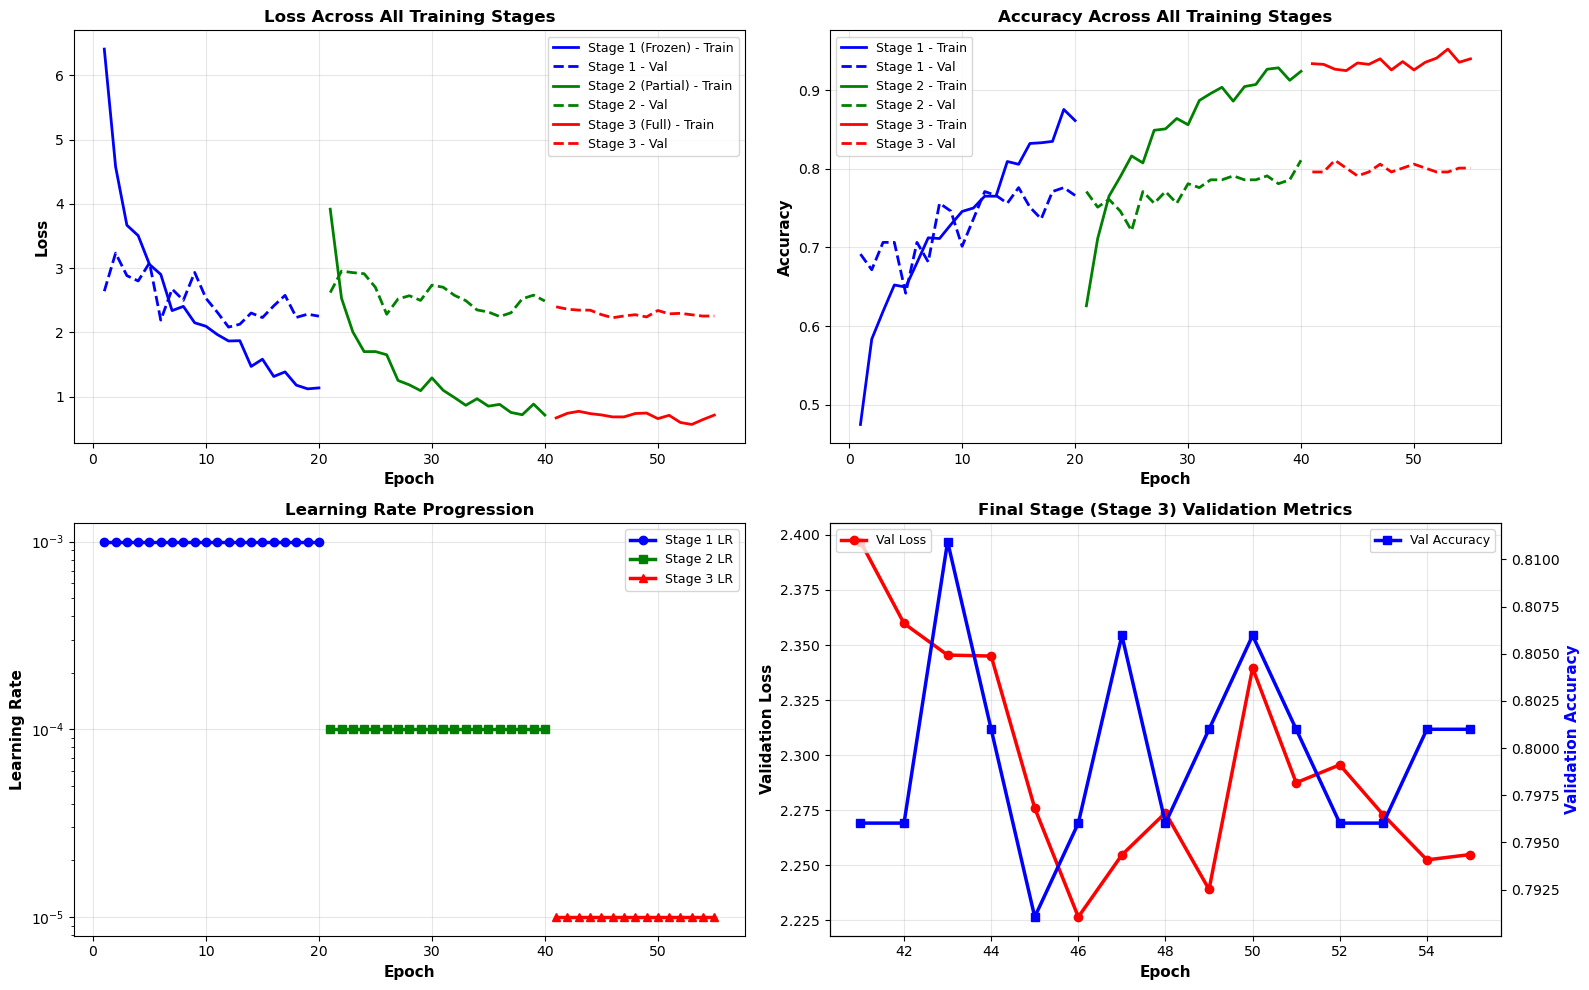

✓ Training history plot saved


In [ ]:

# Plot training curves for all stages
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Combine epoch counts
epochs_s1 = range(1, len(history_stage1.history['loss']) + 1)
epochs_s2 = range(len(history_stage1.history['loss']) + 1,
                 len(history_stage1.history['loss']) + len(history_stage2.history['loss']) + 1)
epochs_s3 = range(len(history_stage1.history['loss']) + len(history_stage2.history['loss']) + 1,
                 len(history_stage1.history['loss']) + len(history_stage2.history['loss']) + len(history_stage3.history['loss']) + 1)

# Loss
ax = axes[0, 0]
ax.plot(epochs_s1, history_stage1.history['loss'], 'b-', linewidth=2, label='Stage 1 (Frozen) - Train')
ax.plot(epochs_s1, history_stage1.history['val_loss'], 'b--', linewidth=2, label='Stage 1 - Val')
ax.plot(epochs_s2, history_stage2.history['loss'], 'g-', linewidth=2, label='Stage 2 (Partial) - Train')
ax.plot(epochs_s2, history_stage2.history['val_loss'], 'g--', linewidth=2, label='Stage 2 - Val')
ax.plot(epochs_s3, history_stage3.history['loss'], 'r-', linewidth=2, label='Stage 3 (Full) - Train')
ax.plot(epochs_s3, history_stage3.history['val_loss'], 'r--', linewidth=2, label='Stage 3 - Val')
ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax.set_ylabel('Loss', fontsize=11, fontweight='bold')
ax.set_title('Loss Across All Training Stages', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Accuracy
ax = axes[0, 1]
ax.plot(epochs_s1, history_stage1.history['accuracy'], 'b-', linewidth=2, label='Stage 1 - Train')
ax.plot(epochs_s1, history_stage1.history['val_accuracy'], 'b--', linewidth=2, label='Stage 1 - Val')
ax.plot(epochs_s2, history_stage2.history['accuracy'], 'g-', linewidth=2, label='Stage 2 - Train')
ax.plot(epochs_s2, history_stage2.history['val_accuracy'], 'g--', linewidth=2, label='Stage 2 - Val')
ax.plot(epochs_s3, history_stage3.history['accuracy'], 'r-', linewidth=2, label='Stage 3 - Train')
ax.plot(epochs_s3, history_stage3.history['val_accuracy'], 'r--', linewidth=2, label='Stage 3 - Val')
ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax.set_title('Accuracy Across All Training Stages', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Learning rate progression through stages
ax = axes[1, 0]
stage1_lr = [CONFIG['learning_rate_stage1']] * len(history_stage1.history['loss'])
stage2_lr = [CONFIG['learning_rate_stage2']] * len(history_stage2.history['loss'])
stage3_lr = [CONFIG['learning_rate_stage3']] * len(history_stage3.history['loss'])
ax.plot(epochs_s1, stage1_lr, 'b-', linewidth=2.5, marker='o', label='Stage 1 LR')
ax.plot(epochs_s2, stage2_lr, 'g-', linewidth=2.5, marker='s', label='Stage 2 LR')
ax.plot(epochs_s3, stage3_lr, 'r-', linewidth=2.5, marker='^', label='Stage 3 LR')
ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax.set_ylabel('Learning Rate', fontsize=11, fontweight='bold')
ax.set_title('Learning Rate Progression', fontsize=12, fontweight='bold')
ax.set_yscale('log')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Zoom in on final stage validation metrics
ax = axes[1, 1]
ax.plot(epochs_s3, history_stage3.history['val_loss'], 'r-', linewidth=2.5, label='Val Loss', marker='o')
ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax.set_ylabel('Validation Loss', fontsize=11, fontweight='bold')
ax2 = ax.twinx()
ax2.plot(epochs_s3, history_stage3.history['val_accuracy'], 'b-', linewidth=2.5, label='Val Accuracy', marker='s')
ax2.set_ylabel('Validation Accuracy', fontsize=11, fontweight='bold', color='blue')
ax.set_title('Final Stage (Stage 3) Validation Metrics', fontsize=12, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax2.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(MODELS_DIR / 'training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Training history plot saved")

In [ ]:
# Save final model in Keras format
final_model_path = MODELS_DIR / 'final_model.keras'
model.save(str(final_model_path))
print(f"✓ Final model saved to {final_model_path}")

# Export model in SavedModel format for better compatibility
final_model_savedmodel_path = MODELS_DIR / 'final_model_savedmodel'
model.export(str(final_model_savedmodel_path))
print(f"✓ Final model exported (SavedModel format) to {final_model_savedmodel_path}")

✓ Final model saved to c:\Users\aarya\OneDrive\Desktop\school\thomasmore\year2\ai\lizardwizard\models\final_model.keras
INFO:tensorflow:Assets written to: c:\Users\aarya\OneDrive\Desktop\school\thomasmore\year2\ai\lizardwizard\models\final_model_savedmodel\assets


INFO:tensorflow:Assets written to: c:\Users\aarya\OneDrive\Desktop\school\thomasmore\year2\ai\lizardwizard\models\final_model_savedmodel\assets


Saved artifact at 'c:\Users\aarya\OneDrive\Desktop\school\thomasmore\year2\ai\lizardwizard\models\final_model_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 384, 384, 3), dtype=tf.float32, name='keras_tensor_385')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  2811927608016: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  2811927606672: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  2811836001424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2811836001808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2811836002960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2811835999888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2811836003152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2811836002384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2811836002192: TensorSpec(shape=(), dtype=tf.resource, name=Non

In [ ]:
# NEW SECTION: Test-Time Augmentation (TTA) for better test predictions
print("\n" + "="*80)
print("IMPLEMENTING TEST-TIME AUGMENTATION (TTA)")
print("="*80)

def create_test_dataset_with_tta(dataframe, batch_size, num_tta=5):
    """Create test dataset for TTA (Test-Time Augmentation).
    
    NOTE: Does NOT modify or reshuffle test data. Each sample is loaded
    with different augmentation to create multiple views.
    """
    
    def load_image_label_tta(row_index):
        row = dataframe.iloc[int(row_index.numpy())]
        img_path = TEST_DIR / f"{row['id']}.jpg"
        img = load_and_preprocess_image(img_path, image_size=CONFIG['image_size'], augment=True)
        return img, tf.cast(row['id'].encode('utf-8'), tf.string)
    
    dataset = tf.data.Dataset.from_tensor_slices(np.arange(len(dataframe)))
    dataset = dataset.map(
        lambda idx: tf.py_function(load_image_label_tta, [idx], (tf.float32, tf.string)),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    
    def set_and_resize_shapes(x, y):
        x.set_shape((None, None, 3))
        target_size = CONFIG['image_size']
        x = tf.image.resize(x, (target_size, target_size))
        x.set_shape((target_size, target_size, 3))
        y.set_shape(())
        return x, y
    
    dataset = dataset.map(set_and_resize_shapes)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    return dataset

# Create TTA dataset (no shuffling - maintains test set integrity)
print("✓ TTA helper created - will be used during test prediction for ensemble averaging")



IMPLEMENTING TEST-TIME AUGMENTATION (TTA)
✓ TTA helper created - will be used during test prediction for ensemble averaging


In [ ]:
# Save training configuration and results
training_results = {
    'config': CONFIG,
    'stage1_best_val_loss': float(min(history_stage1.history['val_loss'])),
    'stage1_best_val_accuracy': float(max(history_stage1.history['val_accuracy'])),
    'stage2_best_val_loss': float(min(history_stage2.history['val_loss'])),
    'stage2_best_val_accuracy': float(max(history_stage2.history['val_accuracy'])),
    'stage3_best_val_loss': float(min(history_stage3.history['val_loss'])),
    'stage3_best_val_accuracy': float(max(history_stage3.history['val_accuracy'])),
    'final_val_accuracy': float(history_stage3.history['val_accuracy'][-1]),
    'final_val_loss': float(history_stage3.history['val_loss'][-1]),
    'class_weights': class_weight_dict,
    'num_training_samples': len(train_df_split),
    'num_validation_samples': len(val_df_split),
}

with open(MODELS_DIR / 'training_results.json', 'w') as f:
    json.dump(training_results, f, indent=2)

print(f"✓ Training results saved to {MODELS_DIR / 'training_results.json'}")

✓ Training results saved to c:\Users\aarya\OneDrive\Desktop\school\thomasmore\year2\ai\lizardwizard\models\training_results.json


In [ ]:
print("\n" + "="*80)
print("TRAINING COMPLETE - SUMMARY")
print("="*80)
print(f"\nStage 1 (Frozen):")
print(f"  Best validation accuracy: {max(history_stage1.history['val_accuracy']):.4f}")
print(f"  Best validation loss: {min(history_stage1.history['val_loss']):.4f}")

print(f"\nStage 2 (Partial unfreeze):")
print(f"  Best validation accuracy: {max(history_stage2.history['val_accuracy']):.4f}")
print(f"  Best validation loss: {min(history_stage2.history['val_loss']):.4f}")

print(f"\nStage 3 (Full unfreeze):")
print(f"  Best validation accuracy: {max(history_stage3.history['val_accuracy']):.4f}")
print(f"  Best validation loss: {min(history_stage3.history['val_loss']):.4f}")
print(f"  Final validation accuracy: {history_stage3.history['val_accuracy'][-1]:.4f}")

print(f"\nModel saved to: {MODELS_DIR}")
print(f"  - final_model.h5 (HDF5 format)")
print(f"  - final_model_savedmodel/ (SavedModel format)")
print(f"  - training_results.json (metrics and config)")
print("="*80)


TRAINING COMPLETE - SUMMARY

Stage 1 (Frozen):
  Best validation accuracy: 0.7761
  Best validation loss: 2.0806

Stage 2 (Partial unfreeze):
  Best validation accuracy: 0.8109
  Best validation loss: 2.2454

Stage 3 (Full unfreeze):
  Best validation accuracy: 0.8109
  Best validation loss: 2.2265
  Final validation accuracy: 0.8010

Model saved to: c:\Users\aarya\OneDrive\Desktop\school\thomasmore\year2\ai\lizardwizard\models
  - final_model.h5 (HDF5 format)
  - final_model_savedmodel/ (SavedModel format)
  - training_results.json (metrics and config)
